# Bab 1: Import Library dan Konfigurasi Path

In [1]:
import os
import random
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, GlobalAveragePooling2D, Rescaling, RandomFlip, RandomRotation, RandomZoom
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix

# Konfigurasi Parameter
DATASET_DIR = Path("Dataset")
TARGET_WIDTH = 224
TARGET_HEIGHT = 224
BATCH_SIZE = 16
EPOCHS = 15
RANDOM_SEED = 42

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

# Deteksi nama kelas
CLASS_NAMES = sorted([d for d in os.listdir(DATASET_DIR) if (DATASET_DIR / d).is_dir()])
NUM_CLASSES = len(CLASS_NAMES)
class_to_idx = {name: i for i, name in enumerate(CLASS_NAMES)}

print("Kelas ditemukan:", CLASS_NAMES)
print("Jumlah kelas   :", NUM_CLASSES)

Kelas ditemukan: ['100k', '10k', '20k', '2k', '50k', '5k']
Jumlah kelas   : 6


# Bab 2: Fungsi Preprocessing (Otsu Thresholding)

In [2]:
def mask_hsv(image_bgr, min_area_ratio=0.01, kernel_size=7):
    if image_bgr is None:
        raise ValueError("Gambar tidak berhasil dibaca.")

    work_img = image_bgr.copy()
    gray = cv2.cvtColor(work_img, cv2.COLOR_BGR2GRAY)
    _, mask = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (kernel_size, kernel_size))
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=1)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=2)

    h, w = mask.shape
    flood = mask.copy()
    flood_mask = np.zeros((h + 2, w + 2), np.uint8)
    cv2.floodFill(flood, flood_mask, (0, 0), 255)

    flood_inv = cv2.bitwise_not(flood)
    mask = mask | flood_inv

    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
    refined = np.zeros_like(mask)

    if num_labels > 1:
        areas = stats[1:, cv2.CC_STAT_AREA]
        largest_idx = 1 + np.argmax(areas)
        largest_area = stats[largest_idx, cv2.CC_STAT_AREA]
        min_area = int(min_area_ratio * h * w)

        if largest_area >= min_area:
            refined[labels == largest_idx] = 255
        else:
            refined = mask.copy()
    else:
        refined = mask.copy()

    result = cv2.bitwise_and(work_img, work_img, mask=refined)
    return work_img, refined, result

def crop_to_mask(image_bgr, mask, pad_ratio=0.05):
    coords = cv2.findNonZero(mask)
    if coords is None:
        return image_bgr

    x, y, w, h = cv2.boundingRect(coords)
    h_img, w_img = image_bgr.shape[:2]
    pad = int(max(w, h) * pad_ratio)

    x1 = max(x - pad, 0)
    y1 = max(y - pad, 0)
    x2 = min(x + w + pad, w_img)
    y2 = min(y + h + pad, h_img)

    return image_bgr[y1:y2, x1:x2]

def resize(image_bgr, target_width, target_height, fill_value=0):
    h, w = image_bgr.shape[:2]
    scale = min(target_width / w, target_height / h)
    new_w = int(round(w * scale))
    new_h = int(round(h * scale))

    resized = cv2.resize(image_bgr, (new_w, new_h), interpolation=cv2.INTER_AREA)
    output = np.full((target_height, target_width, 3), fill_value, dtype=np.uint8)

    x_offset = (target_width - new_w) // 2
    y_offset = (target_height - new_h) // 2
    output[y_offset:y_offset+new_h, x_offset:x_offset+new_w] = resized
    return output

def normalize_minmax(image_bgr):
    return image_bgr.astype(np.float32) / 255.0

# Bab 3: Looping Pengumpulan Data Utama

In [3]:
list_gambar = []
list_label = []

print("Memulai pembacaan dataset dan eksekusi preprocessing...")

for nama_kelas in CLASS_NAMES:
    class_path = DATASET_DIR / nama_kelas
    indeks_kelas = class_to_idx[nama_kelas]
    images_in_folder = [f for f in os.listdir(class_path) if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".webp"))]
    
    for file_img in images_in_folder:
        img_path = class_path / file_img
        img = cv2.imread(str(img_path))
        
        if img is None:
            continue
            
        _, mask, segmented = mask_hsv(img)
        cropped = crop_to_mask(segmented, mask)
        resized = resize(cropped, TARGET_WIDTH, TARGET_HEIGHT)
        
        img_rgb = cv2.cvtColor(resized, cv2.COLOR_BGR2RGB)
        normed = normalize_minmax(img_rgb)
        
        list_gambar.append(normed)
        list_label.append(indeks_kelas)

X = np.array(list_gambar)
y = np.array(list_label)

print(f"Total seluruh data sukses diproses: {X.shape[0]} gambar")

Memulai pembacaan dataset dan eksekusi preprocessing...
Total seluruh data sukses diproses: 192 gambar


# Bab 4: Proses Training Menggunakan 5-Fold Cross Validation

In [4]:
def build_transfer_learning_model():
    base_model = MobileNetV2(input_shape=(TARGET_HEIGHT, TARGET_WIDTH, 3), include_top=False, weights='imagenet')
    base_model.trainable = False  
    
    model = Sequential([
        Input(shape=(TARGET_HEIGHT, TARGET_WIDTH, 3)),
        RandomFlip("horizontal_and_vertical"),
        RandomRotation(0.2),
        RandomZoom(0.1),
        Rescaling(scale=2.0, offset=-1.0),
        base_model,
        GlobalAveragePooling2D(),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(NUM_CLASSES, activation='softmax', dtype='float32')
    ])
    
    model.compile(
        optimizer=Adam(learning_rate=0.0005),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# Setup K-Fold (Kita pakai 5 Fold)
K_FOLDS = 5
skf = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=RANDOM_SEED)

# List untuk menampung performa hasil akhir tiap-tiap fold
rekam_akurasi_fold = []
rekam_loss_fold = []

# List akumulasi prediksi untuk Laporan Klasifikasi global
y_asli_semua = []
y_prediksi_semua = []

os.makedirs('saved_models', exist_ok=True)

# Loop utama Cross Validation
for indeks_fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    print(f"\n==========================================")
    print(f" Memulai Pelatihan: FOLD KE-{indeks_fold + 1} dari {K_FOLDS}")
    print(f"==========================================")
    
    # Memisahkan data berdasarkan indeks fold saat ini
    X_train_f, X_val_f = X[train_idx], X[val_idx]
    y_train_f = tf.keras.utils.to_categorical(y[train_idx], num_classes=NUM_CLASSES)
    y_val_f = tf.keras.utils.to_categorical(y[val_idx], num_classes=NUM_CLASSES)
    
    # Reset model baru setiap fold agar tidak membawa ingatan lama
    tf.keras.backend.clear_session()
    model = build_transfer_learning_model()
    
    # Training model untuk fold ini
    history = model.fit(
        X_train_f, y_train_f,
        validation_data=(X_val_f, y_val_f),
        batch_size=BATCH_SIZE,
        epochs=EPOCHS,
        verbose=1
    )
    
    # Evaluasi hasil akhir fold ini
    loss, acc = model.evaluate(X_val_f, y_val_f, verbose=0)
    rekam_akurasi_fold.append(acc * 100)
    rekam_loss_fold.append(loss)
    print(f"\nHasil Akhir Fold {indeks_fold + 1} -> Akurasi: {acc*100:.2f}%, Loss: {loss:.4f}")
    
    # Simpan prediksi fold ini untuk akumulasi laporan di akhir bab
    pred_f = model.predict(X_val_f, verbose=0)
    y_prediksi_semua.extend(np.argmax(pred_f, axis=1))
    y_asli_semua.extend(y[val_idx])
    
    # Simpan model khusus fold terbaik (misal fold 1 sebagai representasi utama)
    if indeks_fold == 0:
        model.save('models/MobileNetV2CrossVal.keras')
        print("--> Model Fold 1 disimpan sebagai model utama.")


 Memulai Pelatihan: FOLD KE-1 dari 5
Epoch 1/15
10/10 [==============================] - 11s 154ms/step - loss: 2.1359 - accuracy: 0.1503 - val_loss: 1.5650 - val_accuracy: 0.4103
Epoch 2/15
10/10 [==============================] - 1s 83ms/step - loss: 1.4280 - accuracy: 0.4379 - val_loss: 1.3587 - val_accuracy: 0.5641
Epoch 3/15
10/10 [==============================] - 1s 81ms/step - loss: 1.2043 - accuracy: 0.5490 - val_loss: 1.1277 - val_accuracy: 0.7436
Epoch 4/15
10/10 [==============================] - 1s 80ms/step - loss: 1.0417 - accuracy: 0.6536 - val_loss: 1.0348 - val_accuracy: 0.7179
Epoch 5/15
10/10 [==============================] - 1s 82ms/step - loss: 0.8427 - accuracy: 0.7059 - val_loss: 0.9125 - val_accuracy: 0.7692
Epoch 6/15
10/10 [==============================] - 1s 81ms/step - loss: 0.7113 - accuracy: 0.7778 - val_loss: 0.7776 - val_accuracy: 0.8462
Epoch 7/15
10/10 [==============================] - 1s 82ms/step - loss: 0.6393 - accuracy: 0.8366 - val_loss: 0.6

# Bab 5: Rekapitulasi Nilai Rata-Rata Cross Validation & Laporan Akhir

In [5]:
# Cetak Ringkasan Akurasi Tiap Fold (Sangat krusial untuk Bab 4 Skripsimu!)
print("\n==========================================")
print("   RINGKASAN K-FOLD CROSS VALIDATION")
print("==========================================")
for i in range(K_FOLDS):
    print(f"• Fold ke-{i+1} : Akurasi = {rekam_akurasi_fold[i]:.2f}% | Loss = {rekam_loss_fold[i]:.4f}")
print("-" * 42)
print(f"👉 RATA-RATA AKURASI K-FOLD : {np.mean(rekam_akurasi_fold):.2f}%")
print(f"👉 RATA-RATA LOSS K-FOLD    : {np.mean(rekam_loss_fold):.4f}")


   RINGKASAN K-FOLD CROSS VALIDATION
• Fold ke-1 : Akurasi = 92.31% | Loss = 0.3224
• Fold ke-2 : Akurasi = 97.44% | Loss = 0.3210
• Fold ke-3 : Akurasi = 92.11% | Loss = 0.3638
• Fold ke-4 : Akurasi = 81.58% | Loss = 0.4395
• Fold ke-5 : Akurasi = 94.74% | Loss = 0.3697
------------------------------------------
👉 RATA-RATA AKURASI K-FOLD : 91.63%
👉 RATA-RATA LOSS K-FOLD    : 0.3633


In [6]:
# Mengubah akumulasi list ke array numpy untuk dievaluasi
y_asli_semua = np.array(y_asli_semua)
y_prediksi_semua = np.array(y_prediksi_semua)

# Menampilkan Laporan Hasil Klasifikasi Keseluruhan Fold
print("\n📊 LAPORAN KLASIFIKASI GLOBAL (AKUMULASI 5-FOLD):\n")
print(classification_report(y_asli_semua, y_prediksi_semua, target_names=CLASS_NAMES, zero_division=0))


📊 LAPORAN KLASIFIKASI GLOBAL (AKUMULASI 5-FOLD):

              precision    recall  f1-score   support

        100k       1.00      1.00      1.00        32
         10k       0.81      0.81      0.81        32
         20k       0.91      0.97      0.94        32
          2k       0.81      0.94      0.87        32
         50k       1.00      1.00      1.00        32
          5k       1.00      0.78      0.88        32

    accuracy                           0.92       192
   macro avg       0.92      0.92      0.92       192
weighted avg       0.92      0.92      0.92       192



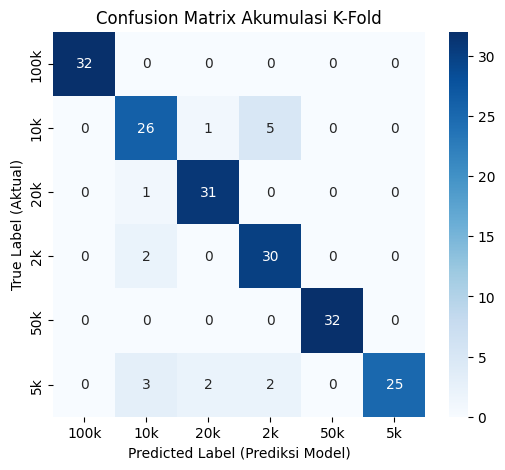

In [7]:
# Visualisasi Heatmap Confusion Matrix Akumulasi
plt.figure(figsize=(6, 5))
matriks_evaluasi = confusion_matrix(y_asli_semua, y_prediksi_semua)
sns.heatmap(matriks_evaluasi, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix Akumulasi K-Fold')
plt.ylabel('True Label (Aktual)')
plt.xlabel('Predicted Label (Prediksi Model)')
plt.show()

✅ Model berhasil dimuat dari penyimpan lokal!


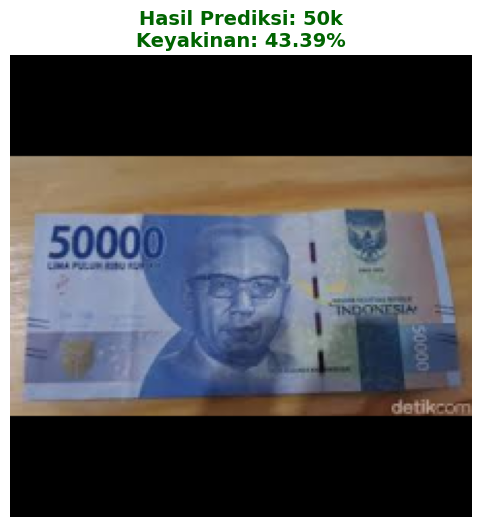

👉 Kesimpulan: Model mendeteksi gambar tersebut sebagai pecahan '50k' (43.39%).


In [11]:
from tensorflow.keras.models import load_model

PATH_GAMBAR_BARU = "tester50k.png" 

# 2. Memuat kembali seluruh model yang sudah dilatih sebelumnya
path_model_saved = 'models/MobileNetV2CrossVal.keras'

if os.path.exists(path_model_saved):
    model_demo = load_model(path_model_saved)
    print("✅ Model berhasil dimuat dari penyimpan lokal!")
else:
    print("❌ File model tidak ditemukan! Pastikan kamu sudah menjalankan Bab 4 sampai selesai.")
    model_demo = None

# Jalankan prediksi jika model dan gambar tersedia
if model_demo is not None:
    # 3. Membaca gambar baru menggunakan OpenCV
    img_bgr_baru = cv2.imread(PATH_GAMBAR_BARU)

    if img_bgr_baru is None:
        print(f"❌ Gagal membaca gambar! Periksa kembali apakah file '{PATH_GAMBAR_BARU}' sudah ada di foldermu.")
    else:
        # 4. Menjalankan fungsi preprocessing aslimu secara berurutan
        _, mask_baru, segmented_baru = mask_hsv(img_bgr_baru)
        cropped_baru = crop_to_mask(segmented_baru, mask_baru)
        resized_baru = resize(cropped_baru, TARGET_WIDTH, TARGET_HEIGHT)
        
        # Konversi warna ke RGB dan normalisasi [0, 1]
        img_rgb_baru = cv2.cvtColor(resized_baru, cv2.COLOR_BGR2RGB)
        normed_baru = normalize_minmax(img_rgb_baru)

        # 5. Mengubah dimensi gambar menjadi (1, 256, 256, 3) agar sesuai input batch model
        input_tensor = np.expand_dims(normed_baru, axis=0)

        # 6. Melakukan prediksi skor kecocokan kelas
        skor_prediksi = model_demo.predict(input_tensor, verbose=0)
        indeks_tertinggi = np.argmax(skor_prediksi, axis=1)[0]
        
        # Ambil nama kelas dan persentase keyakinan model
        nama_prediksi = CLASS_NAMES[indeks_tertinggi]
        persen_keyakinan = skor_prediksi[0][indeks_tertinggi] * 100

        # 7. Menampilkan gambar hasil preprocessing beserta teks hasil tebakan model
        plt.figure(figsize=(6, 6))
        plt.imshow(img_rgb_baru)
        plt.title(f"Hasil Prediksi: {nama_prediksi}\nKeyakinan: {persen_keyakinan:.2f}%", 
                  fontsize=14, fontweight='bold', color='darkgreen')
        plt.axis('off')
        plt.show()

        print(f"👉 Kesimpulan: Model mendeteksi gambar tersebut sebagai pecahan '{nama_prediksi}' ({persen_keyakinan:.2f}%).")